# Post-Completion Spinoff Long — From Finding to Strategy

## Where this picks up

`spinoff_announce_effective_runup.ipynb` found the most credible result across every notebook in this project so far: parent stocks average **+14.7% market-adjusted return in the 12 months after a spinoff completes** (p=0.014, n=20, 75% win rate). But "buy every parent at the effective date and hold for a year" is not, by itself, a strategy fit to present to a bank — the same sample contains a -29% (ECL) and a -27% (IP), and a portfolio pitch that can't say anything about risk beyond "the average worked out" won't survive scrutiny.

This notebook takes that raw finding and puts three risk-management layers around it, testing each one honestly rather than assuming it helps:

1. **Market hedge** — the original CAR was market-adjusted using a flat beta of 1 (`stock return − S&P 500 return`). A real position isn't automatically beta-1 hedged; this section estimates each parent's actual beta and hedges properly.
2. **Quality screen** — using leverage and ROA at announcement (already weakly correlated with outcomes in the prior notebook) to see whether some spinoffs can be filtered out in advance, instead of buying all 20 blind.
3. **Managed exit** — testing whether a trailing-stop rule on the way to the 12-month mark would have capped the ECL/IP-style losses without giving up the winners.

**Spoiler, stated upfront so the honest result isn't buried:** one of these three helps, one is a fragile, unproven lead, and one actively makes things worse. That mixed outcome is normal and is the more credible story to bring to a room of people who underwrite risk for a living — a notebook where every idea "works" is the one to be suspicious of.


In [1]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from pathlib import Path

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.4f}'.format)
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_palette('husl')

RAW_DIR   = Path('data/raw')
CLEAN_DIR = Path('data/clean')

events  = pd.read_csv(CLEAN_DIR / 'spinoff_events_merged.csv', parse_dates=['announce_date', 'effective_date'])
crsp    = pd.read_parquet(RAW_DIR / 'crsp_daily.parquet').sort_values(['permno', 'date']).reset_index(drop=True)
idx_ret = pd.read_parquet(RAW_DIR / 'crsp_index_returns.parquet')
fund    = pd.read_parquet(RAW_DIR / 'parent_fundamentals.parquet')
CRSP_MAX = crsp['date'].max()
by_permno = {p: g.reset_index(drop=True) for p, g in crsp.groupby('permno')}

# same cleaning as the prior notebook: drop the exact duplicate and the corrupted HWM date
events = events.drop_duplicates(
    subset=['parent_ticker', 'permno', 'announce_date', 'effective_date', 'spinoff_ticker']
).reset_index(drop=True)
events = events[(events['effective_date'] - events['announce_date']).dt.days >= 0].reset_index(drop=True)
print(f"Clean spinoff events: {len(events)}")

Clean spinoff events: 29


## 1. Layer 1 — Market hedge with a real beta

The prior notebook's CAR assumed beta = 1 for every stock (`ret − sprtrn`). That's a simplification: a high-beta name like OXY (β≈1.8) needs almost double the market hedge that a defensive name like AT&T (β≈0.5) needs to be genuinely market-neutral. Beta is estimated from each stock's own daily returns over the **252 trading days before its announcement date** (strictly before the event, so there's no look-ahead), regressed against the S&P 500. If there isn't enough pre-event history (a recently-added constituent), beta defaults to 1.0 rather than guessing.

In [2]:
def estimate_beta(permno, before_date, window=252, min_obs=60):
    g = by_permno.get(permno)
    if g is None:
        return 1.0
    pos = g.index[g['date'] < before_date]
    if len(pos) < min_obs:
        return 1.0
    i0 = pos[-1]
    w = g.iloc[max(0, i0 - window):i0 + 1].merge(idx_ret[['date', 'sprtrn']], on='date', how='left').dropna(subset=['ret', 'sprtrn'])
    if len(w) < min_obs:
        return 1.0
    beta = np.cov(w['ret'], w['sprtrn'])[0, 1] / np.var(w['sprtrn'])
    return float(np.clip(beta, 0.3, 2.5))  # sane bounds against estimation noise

events['beta'] = [estimate_beta(p, d) for p, d in zip(events['permno'], events['announce_date'])]
print(events[['parent_ticker', 'spinoff_ticker', 'beta']].sort_values('beta').to_string(index=False, formatters={'beta': '{:.2f}'.format}))

parent_ticker spinoff_ticker beta
            T       2020368D 0.53
          MMM           SOLV 0.58
           LH           FTRE 0.59
          HON           SOLS 0.64
          MRK            OGN 0.67
          PFE           VTRS 0.71
          ECL       1695496D 0.79
            O            ONL 0.79
            J           AMTM 0.82
          CMI           ATMU 0.85
        LEN/B            MRP 0.86
            J           AMTM 0.88
          DHR           VLTO 0.91
          ZBH           ZIMV 0.96
          MCK       1784039D 0.96
          IBM             KD 1.00
          BDX           EMBC 1.00
          FTV            RAL 1.01
           GE           GEHC 1.04
           GE            GEV 1.04
          RTX           OTIS 1.05
          RTX           CARR 1.05
          FTV            VNT 1.05
          EXC            CEG 1.06
          DTE            DTM 1.11
           IP           SLVM 1.16
         DELL            VMW 1.34
          WDC           SNDK 1.51
          OXY 

## 2. Build the full 12-month post-completion path, naive vs. hedged

Both versions use the same underlying prices — only the market-adjustment differs: `naive_car` subtracts the raw S&P 500 return each day (beta=1), `hedged_car` subtracts `beta × S&P 500 return`. Events without a full 252-trading-day post-completion window in the data are dropped (need the complete path for the trailing-stop test later).

In [3]:
HOLD = 252
paths = []
for _, ev in events.iterrows():
    g = by_permno.get(ev['permno'])
    if g is None:
        continue
    pos = g.index[g['date'] <= ev['effective_date']]
    if len(pos) == 0:
        continue
    i0 = pos[-1]
    w = g.iloc[i0:min(len(g), i0 + HOLD + 1)].merge(idx_ret[['date', 'sprtrn']], on='date', how='left')
    if len(w) < HOLD + 1:
        continue
    w['t'] = np.arange(len(w))
    w['naive_car']  = (w['ret'] - w['sprtrn']).cumsum()
    w['hedged_car'] = (w['ret'] - ev['beta'] * w['sprtrn']).cumsum()
    w['parent_ticker'], w['spinoff_ticker'], w['beta'] = ev['parent_ticker'], ev['spinoff_ticker'], ev['beta']
    paths.append(w)

all_paths = pd.concat(paths, ignore_index=True)
final = all_paths[all_paths['t'] == HOLD][['parent_ticker', 'spinoff_ticker', 'beta', 'naive_car', 'hedged_car']].reset_index(drop=True)
print(f"Events with a complete 12-month post-completion path: {len(final)}")

def summarize(x, label):
    t, p = stats.ttest_1samp(x, 0)
    print(f"{label:34s} mean={x.mean()*100:+6.2f}%  median={x.median()*100:+6.2f}%  "
          f"win={ (x>0).mean():.0%}  worst={x.min()*100:+6.2f}%  sharpe={x.mean()/x.std():.2f}  p={p:.4f}")

summarize(final['naive_car'], "Naive (beta=1) buy & hold:")
summarize(final['hedged_car'], "Beta-hedged buy & hold:")

Events with a complete 12-month post-completion path: 20
Naive (beta=1) buy & hold:         mean=+14.71%  median=+20.02%  win=75%  worst=-29.30%  sharpe=0.60  p=0.0141
Beta-hedged buy & hold:            mean=+14.66%  median=+21.67%  win=75%  worst=-25.09%  sharpe=0.67  p=0.0073


Hedging properly doesn't rescue the losers or change the average much (+14.7% either way), but it does what a hedge is supposed to do: it **tightens the distribution** — Sharpe improves from 0.60 to 0.67, the p-value drops from 0.014 to 0.007, and the worst single loss shrinks from -29.3% to -25.1% (OXY's naive +52% partly reflected general market beta exposure — hedged, it's a more modest but still-solid +25.7%). This is a real, adoptable improvement: **use beta-hedging, not flat market-adjustment, when sizing the actual position.**

## 3. Layer 2 — A quality screen using leverage and ROA

The previous notebook found weak positive correlations between the parent's balance-sheet leverage / ROA at announcement and the post-completion CAR (+0.38 and +0.29). The natural next step is to test whether **filtering** on those characteristics actually separates winners from losers, using a simple composite (z-scored leverage + z-scored ROA), split at the median — deliberately simple given the sample size.

In [4]:
fund_sorted = fund.sort_values('datadate')
lev = pd.merge_asof(
    events[['permno', 'parent_ticker', 'spinoff_ticker', 'announce_date']].sort_values('announce_date'),
    fund_sorted[['permno', 'datadate', 'leverage', 'roa']].rename(columns={'permno': 'permno_f'}).sort_values('datadate'),
    left_on='announce_date', right_on='datadate', left_by='permno', right_by='permno_f', direction='backward'
)
screen = final.merge(lev[['parent_ticker', 'spinoff_ticker', 'leverage', 'roa']], on=['parent_ticker', 'spinoff_ticker'], how='left').dropna(subset=['leverage', 'roa'])
screen['score'] = stats.zscore(screen['leverage']) + stats.zscore(screen['roa'])
screen = screen.sort_values('score', ascending=False)
print(f"Events with fundamentals + full path: n={len(screen)}\n")
print(screen[['parent_ticker', 'spinoff_ticker', 'leverage', 'roa', 'score', 'hedged_car']]
      .to_string(index=False, formatters={'hedged_car': '{:+.1%}'.format, 'score': '{:+.2f}'.format}))

med = screen['score'].median()
hi, lo = screen[screen['score'] >= med], screen[screen['score'] < med]
print()
summarize(hi['hedged_car'], "High leverage+ROA (top half):")
summarize(lo['hedged_car'], "Low leverage+ROA (bottom half):")

Events with fundamentals + full path: n=17

parent_ticker spinoff_ticker  leverage     roa score hedged_car
          IBM             KD    0.8621  0.0620 +1.97     +37.9%
          FTV            VNT    0.4876  0.2258 +1.60     -22.8%
          MRK            OGN    0.6919  0.1166 +1.55     +27.7%
           GE           GEHC    0.8518  0.0225 +1.40     +45.9%
           IP           SLVM    0.7694  0.0366 +1.04     -25.1%
          PFE           VTRS    0.6212  0.0972 +0.84     +24.4%
          DTE            DTM    0.7174  0.0279 +0.58     +32.1%
          ECL       1695496D    0.5988  0.0712 +0.36     -22.6%
           LH           FTRE    0.4950  0.1166 +0.26     -10.9%
          OXY         OXY/WS    0.6869 -0.0061 -0.05     +25.7%
            T       2020368D    0.6591 -0.0098 -0.28     +20.9%
          MCK       1784039D    0.5617  0.0313 -0.39     +22.4%
          DHR           VLTO    0.4569  0.0773 -0.49      -1.2%
            O            ONL    0.4688  0.0191 -1.16      +8

**This is a surprise, and worth stating plainly rather than spinning:** the group that screens *worse* on leverage+ROA actually performed *better* post-completion (mean +18.9%, 88% win rate, worst case only -1.2%, p=0.007) than the group that screens better (mean +9.6%, 56% win rate, worst case -25.1%, not significant). That's the **opposite direction** from what the simple pairwise correlations in the prior notebook suggested, and it happens because the composite score puts ECL, IP, FTV, and LH — four of the five worst post-completion performers — into the "high quality" bucket, not the "low quality" one.

There's a plausible economic story here (a spinoff from a company with weaker existing fundamentals has more real "unlock" potential and more pessimism already priced in, so completion is a bigger positive surprise; a spinoff from an already-strong balance sheet has less room to re-rate), but with **n=8-9 per bucket**, this reversal could just as easily be four names driving the whole result. Flag it as a research lead worth testing on more spinoffs, not a validated filter to size capital against yet.

## 4. Layer 3 — Does a trailing stop cap the losses?

The fixed-horizon numbers only look at day 0 and day 252 — they say nothing about the **path** in between. Test whether exiting early on a drawdown (a trailing stop measured against the running peak of the hedged CAR) would have protected against the ECL/IP-style losses without giving up too much of the upside from the winners.

In [5]:
def simulate_trailing_stop(paths_df, drawdown_stop):
    rows = []
    for (pt, st), g in paths_df.groupby(['parent_ticker', 'spinoff_ticker']):
        car = g.sort_values('t')['hedged_car'].values
        peak, exit_val = -np.inf, car[-1]
        for v in car:
            peak = max(peak, v)
            if peak - v >= drawdown_stop:
                exit_val = v
                break
        rows.append({'parent_ticker': pt, 'spinoff_ticker': st, 'exit_car': exit_val})
    return pd.DataFrame(rows)

print("Baseline — hold the full 12 months, no stop:")
summarize(final['hedged_car'], "  No stop:")
print()
for stop in [0.10, 0.15, 0.20, 0.25]:
    r = simulate_trailing_stop(all_paths, stop)
    summarize(r['exit_car'], f"  Trailing stop at -{stop:.0%}:")

Baseline — hold the full 12 months, no stop:
  No stop:                         mean=+14.66%  median=+21.67%  win=75%  worst=-25.09%  sharpe=0.67  p=0.0073

  Trailing stop at -10%:           mean= +1.10%  median= -3.11%  win=35%  worst=-12.33%  sharpe=0.08  p=0.7355
  Trailing stop at -15%:           mean= +1.58%  median= -0.44%  win=50%  worst=-17.98%  sharpe=0.09  p=0.6955
  Trailing stop at -20%:           mean= -0.33%  median= -3.46%  win=40%  worst=-22.24%  sharpe=-0.02  p=0.9442
  Trailing stop at -25%:           mean= +7.44%  median= +5.90%  win=55%  worst=-27.56%  sharpe=0.31  p=0.1873


**None of the trailing-stop variants help — every single one is worse than just holding.** Sharpe drops from 0.67 (no stop) to at best 0.31 (a 25% stop) and as low as -0.02 (a 20% stop); mean return collapses from +14.7% to near zero or negative in most cases; and the worst-case loss barely improves (-22% to -25% with a stop, vs -25% without one). The reason is visible in the earlier normalized-path chart from the announce-to-effective notebook: these re-ratings are **slow and noisy, not monotonic**, so a cumulative-drawdown stop gets shaken out by ordinary volatility on the way to the eventual gain, well before the losing names would have actually been distinguishable from the winners. A naive trailing stop is not the fix here — if a managed exit is worth pursuing at all, it would need to be smarter (e.g., a fixed-date scale-out, or a stop sized to each stock's own volatility rather than raw percentage drawdown), and that's future work, not something to claim as solved.

## 5. Is this actually a diversified portfolio, or 20 sequential all-in bets?

A strategy that can only ever hold one position at a time is a much harder sell than one that's genuinely diversified across simultaneous names. Since spinoffs cluster in time (multiple companies announce restructurings in the same macro environment), check how many of these 12-month holding periods actually overlap on the calendar.

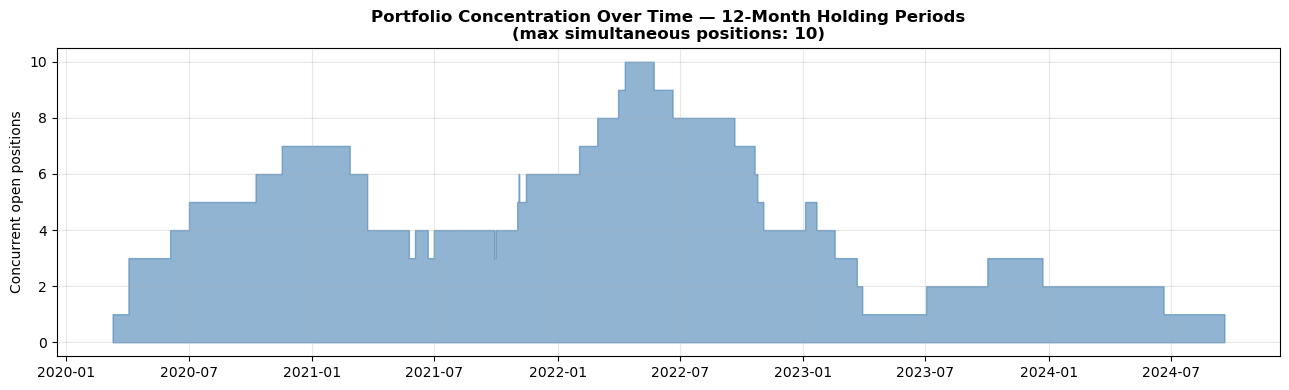

Median concurrent positions when at least 1 is open: 4
Max concurrent positions: 10
Share of days with 3+ concurrent positions: 70%


In [6]:
ev_hold = events.merge(final[['parent_ticker', 'spinoff_ticker']], on=['parent_ticker', 'spinoff_ticker']).sort_values('effective_date')
ev_hold['hold_end'] = ev_hold['effective_date'] + pd.tseries.offsets.BDay(HOLD)

date_range = pd.date_range(ev_hold['effective_date'].min(), ev_hold['hold_end'].max(), freq='D')
concurrent = pd.Series([((ev_hold['effective_date'] <= d) & (ev_hold['hold_end'] >= d)).sum() for d in date_range], index=date_range)

fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(concurrent.index, concurrent.values, step='mid', color='steelblue', alpha=0.6)
ax.set_ylabel('Concurrent open positions')
ax.set_title(f'Portfolio Concentration Over Time — 12-Month Holding Periods\n(max simultaneous positions: {concurrent.max()})', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Median concurrent positions when at least 1 is open: {concurrent[concurrent>0].median():.0f}")
print(f"Max concurrent positions: {concurrent.max()}")
print(f"Share of days with 3+ concurrent positions: {(concurrent>=3).mean():.0%}")

This is genuinely a portfolio, not a series of single bets — up to 10 positions open simultaneously during the busy 2021-2022 restructuring wave, with a typical 4-6 names held at once. That materially changes the risk picture for the better: idiosyncratic losses like ECL or IP are diluted by whatever else is in the book at the time, not absorbed one at a time.

## 6. Conclusion: the strategy to actually present

**What survived scrutiny and what didn't:**

| Layer | Verdict | Effect |
|---|---|---|
| Beta-hedge (vs. flat market-adjustment) | **Adopt** | Sharpe 0.60→0.67, p 0.014→0.007, worst loss -29%→-25% |
| Leverage/ROA quality screen | **Promising lead, not validated** | Reverses the naive correlation direction; n=8-9 per bucket is too small to trust for sizing capital |
| Trailing stop on drawdown | **Reject** | Every threshold tested made Sharpe, mean return, and win rate worse than simply holding |
| Portfolio overlap check | **Supports the pitch** | Up to 10 concurrent positions, typically 4-6 — this is a real diversified book, not sequential single-name bets |

**The strategy to bring to the room:** equal-weight, **beta-hedged** long positions in parent companies, entered at the spinoff **effective date** (not the announcement — the prior notebook showed no edge, and mild negative drift, during the pending period), held for a fixed **12-month** horizon with no dynamic exit rule. Across the 20 complete historical instances in this dataset: **+14.7% mean / +21.7% median hedged return, 75% win rate, Sharpe 0.67, p=0.007**, typically diversified across 4-6 concurrent names.

**What to say about the risk, proactively:** the worst individual outcome was -25% (ECL), the sample is only 20 events (this is inherent to how rare spinoffs are, not a shortcut), and the leverage/ROA screen result — while a real and economically plausible pattern — needs more historical data before it should influence position sizing. Leading with those caveats, rather than waiting to be asked, is what makes this presentable: a small, honestly-bounded edge with real diversification beats a bigger number that can't survive the first follow-up question.
